# Phase 2: Data Understanding

**CRISP-DM Phase Description:**  
This phase involves acquiring the data, getting familiar with it, identifying data quality problems, and detecting initial insights. A thorough understanding of the data at this stage is critical for a successful project.

---

In [1]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
%matplotlib inline

---
### Task 1: Collect Initial Data

Acquire the necessary data and load it into the analysis environment. This task includes:

- **Data Acquisition:** Load data from files, databases, APIs, or other sources.
- **Initial Data Report:** Document the data source(s), the method of acquisition, and any problems encountered during loading.

**Instructions:**
1. Update the file path(s) below to point to your actual dataset(s).
2. Load the data into a Pandas DataFrame.
3. Display a small sample of the data to confirm it loaded correctly.

In [2]:
# Task 1: Collect Initial Data

import pandas as pd
DATA_PATH = "/Users/ahmedsaleh/Desktop/Data science project/data/processed/donordataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

df.head()

Dataset loaded successfully.
Number of rows: 109248
Number of columns: 14


,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary
0,p253737,mrs,in,grades_prek_2,literacy_language,esl_literacy,0,0,154.60,23,educational support english learners home,students english learners working english seco...,students_need_opportunities_practice_beginning...,0
1,p258326,mr,fl,grades_6_8,history_civics_health_sports,civics_government_teamsports,7,1,299.00,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students_need_projector_help_viewing_education...,0
2,p182444,ms,az,grades_6_8,health_sports,health_wellness_teamsports,1,0,516.85,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students_need_shine_guards_athletic_socks_socc...,0
3,p246581,mrs,ky,grades_prek_2,literacy_language_math_science,literacy_mathematics,4,1,232.90,4,techie kindergarteners,work unique school filled esl english second l...,students_need_engage_reading_math_way_inspire_...,0
4,p104768,mrs,tx,grades_prek_2,math_science,mathematics,1,1,67.98,4,interactive math tools,second grade classroom next year made around 2...,students_need_hands_practice_mathematics_fun_p...,0


In [3]:
# Verify the data loaded correctly by displaying shape and a sample
# print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
# df.sample(5)

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.sample(5)

Dataset shape: 109248 rows x 14 columns


,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary
55373,p058800,ms,tx,grades_3_5,math_science,environmentalscience,8,0,199.00,1,class pet doubles microgarden,third grade science social studies teacher sma...,students_need_class_pet_not_teaches_responsibi...,0
97790,p084182,mrs,ny,grades_prek_2,literacy_language,literacy,0,1,475.12,16,kindergarten students need lower level books i...,begin exciting year group 17 kindergarten stud...,students_need_leveled_texts_classroom_practice...,0
20063,p114723,mrs,pa,grades_3_5,literacy_language_specialneeds,literature_writing_specialneeds,1,1,672.93,6,growth mindset age stem,creativity intelligence fun quote albert einst...,students_need_ipads_keyboards_cases_engage_mul...,0
48549,p014268,mrs,mi,grades_prek_2,literacy_language_math_science,literacy_mathematics,3,1,326.95,8,bringing big technology little hands,teach wonderful group first grade students com...,students_need_four_ipad_minis_help_whole_small...,0
8005,p016697,ms,wv,grades_3_5,literacy_language,literacy,4,0,219.18,7,essentials excellent students,energy enthusiasm willingness learn makes stud...,students_need_essential_classroom_supplies_ord...,0


In [4]:
# Document data source details
# data_source_report = {
#     "source": "",           # e.g., "Kaggle", "Internal Database", "Public API"
#     "acquisition_method": "", # e.g., "CSV download", "SQL query", "API call"
#     "date_acquired": "",
#     "issues_encountered": []  # e.g., ["Encoding issues with special characters"]
# }
# print(data_source_report)

data_source_report = {
    "source": "Kaggle - DonorsChoose Application Screening dataset",
    
    "acquisition_method": "Dataset downloaded as a CSV file from Kaggle and loaded into Python using pandas (pd.read_csv)",
    
    "date_acquired": "06/04/2026",
    
    "issues_encountered": [
        "Initial file permission error when accessing the dataset from the Downloads folder, resolved by moving the file to the project directory",
        "Missing Python libraries such as matplotlib and seaborn required installation before running analysis",
        "Dataset required initial inspection to understand column structure and data types",
        "Presence of categorical variables required encoding for use in machine learning models"
    ]
}

print("Data Source Report ")
for key, value in data_source_report.items():
    print(f"\n{key.upper()}:")
    print(value)


Data Source Report 

SOURCE:
Kaggle - DonorsChoose Application Screening dataset

ACQUISITION_METHOD:
Dataset downloaded as a CSV file from Kaggle and loaded into Python using pandas (pd.read_csv)

DATE_ACQUIRED:
06/04/2026

ISSUES_ENCOUNTERED:
['Initial file permission error when accessing the dataset from the Downloads folder, resolved by moving the file to the project directory', 'Missing Python libraries such as matplotlib and seaborn required installation before running analysis', 'Dataset required initial inspection to understand column structure and data types', 'Presence of categorical variables required encoding for use in machine learning models']


---
### Task 2: Describe Data

Examine the "surface" properties of the acquired data. This includes:

- **Volume:** How many records (rows) and attributes (columns) does the dataset contain?
- **Field Identities:** What are the names, data types, and roles (ID, feature, target) of each column?
- **Descriptive Statistics:** What are the basic statistics (mean, median, std, min, max) of the numerical features and frequency counts for categorical features?

**Instructions:** Use Pandas built-in methods (`.info()`, `.describe()`, `.dtypes`, `.value_counts()`) to generate a comprehensive description of your data.

In [5]:
print("DATASET STRUCTURE ")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\nCOLUMN NAMES")
print(df.columns.tolist())

print("\nDATA TYPES & NON-NULL COUNTS")
df.info()

DATASET STRUCTURE 
Rows: 109248
Columns: 14

COLUMN NAMES
['id', 'teacher_prefix', 'school_state', 'project_grade_category', 'project_subject_categories', 'project_subject_subcategories', 'teacher_number_of_previously_posted_projects', 'project_is_approved', 'price', 'quantity', 'cleaned_titles', 'cleaned_essays', 'cleaned_summary', 'isdigit_summary']

DATA TYPES & NON-NULL COUNTS
<class 'pandas.DataFrame'>
RangeIndex: 109248 entries, 0 to 109247
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   id                                            109248 non-null  str    
 1   teacher_prefix                                109248 non-null  str    
 2   school_state                                  109248 non-null  str    
 3   project_grade_category                        109248 non-null  str    
 4   project_subject_categories                    109248 no

In [6]:
print("""
Data Description:

The dataset contains over 100,000 records and 14 columns, indicating a moderately large dataset suitable for analysis.
The features include a mix of categorical variables, such as teacher prefix, school state, and project categories.
and numerical variables (such as the number of previously posted projects).

The target variable is 'project_is_approved', which represents whether a project received funding.

The dataset appears to be complete with minimal missing values, making it suitable for machine learning after preprocessing.
""")


Data Description:

The dataset contains over 100,000 records and 14 columns, indicating a moderately large dataset suitable for analysis.
The features include a mix of categorical variables, such as teacher prefix, school state, and project categories.
and numerical variables (such as the number of previously posted projects).

The target variable is 'project_is_approved', which represents whether a project received funding.

The dataset appears to be complete with minimal missing values, making it suitable for machine learning after preprocessing.



In [7]:
# Generate descriptive statistics for numerical columns
df.describe()

,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,isdigit_summary
count,109248.000000,109248.000000,109248.000000,109248.000000,109248.000000
mean,11.153165,0.848583,298.119343,16.965610,0.144222
std,27.777154,0.358456,367.498030,26.182942,0.351317
min,0.000000,0.000000,0.660000,1.000000,0.000000
25%,0.000000,1.000000,104.310000,4.000000,0.000000
50%,2.000000,1.000000,206.220000,9.000000,0.000000
75%,9.000000,1.000000,379.000000,21.000000,0.000000
max,451.000000,1.000000,9999.000000,930.000000,1.000000


In [8]:
print("""

The descriptive statistics provide an overview of the numerical features in the dataset.
For example, the feature 'teacher_number_of_previously_posted_projects' shows variation across teachers, 
indicating different levels of experience. The presence of both minimum and maximum values suggests 
that some teachers are significantly more active than others.
Understanding these distributions is important, as numerical features may influence the likelihood 
of project approval and will later be used in model training.
""")



The descriptive statistics provide an overview of the numerical features in the dataset.
For example, the feature 'teacher_number_of_previously_posted_projects' shows variation across teachers, 
indicating different levels of experience. The presence of both minimum and maximum values suggests 
that some teachers are significantly more active than others.
Understanding these distributions is important, as numerical features may influence the likelihood 
of project approval and will later be used in model training.



In [9]:
# Generate descriptive statistics for categorical columns
# df.describe(include='object')

# Or inspect value counts for specific categorical columns:
# for col in df.select_dtypes(include='object').columns:
#     print(f"\n--- {col} ---")
#     print(df[col].value_counts())

print("\n VALUE COUNTS FOR CATEGORICAL FEATURES ")

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(10))  


 VALUE COUNTS FOR CATEGORICAL FEATURES 

--- id ---
id
p253737    1
p258326    1
p182444    1
p246581    1
p104768    1
p154343    1
p099819    1
p092424    1
p045029    1
p001713    1
Name: count, dtype: int64

--- teacher_prefix ---
teacher_prefix
mrs        57272
ms         38955
mr         10648
teacher     2360
dr            13
Name: count, dtype: int64

--- school_state ---
school_state
ca    15388
tx     7396
ny     7318
fl     6185
nc     5091
il     4350
ga     3963
sc     3936
mi     3161
pa     3109
Name: count, dtype: int64

--- project_grade_category ---
project_grade_category
grades_prek_2    44225
grades_3_5       37137
grades_6_8       16923
grades_9_12      10963
Name: count, dtype: int64

--- project_subject_categories ---
project_subject_categories
literacy_language                    23655
math_science                         17072
literacy_language_math_science       14636
health_sports                        10177
music_arts                            5180
specia

/var/folders/tr/fdgsl4js4h7bntph32g33nt40000gn/T/ipykernel_94476/2544985845.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


---
### Task 3: Explore Data

Dig deeper into the data using querying, visualisation, and statistical analysis to find initial insights, patterns, and interesting subsets. Key activities include:

- **Univariate Analysis:** Examine the distribution of individual features using histograms, box plots, and bar charts.
- **Bivariate / Multivariate Analysis:** Explore relationships between features using scatter plots, correlation matrices, and grouped summaries.
- **Initial Hypotheses:** Formulate initial hypotheses based on observed patterns.

**Instructions:** Create visualisations and run queries to understand the distributions, relationships, and patterns in your data.

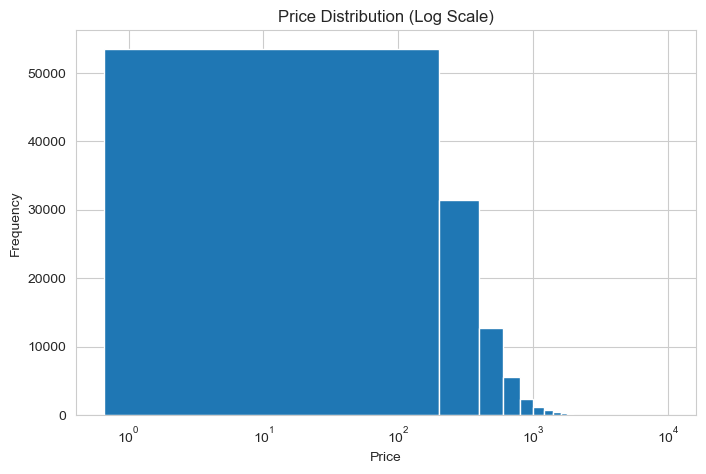

In [10]:
import matplotlib.pyplot as plt

if 'price' in df.columns:
    plt.figure(figsize=(8,5))
    plt.hist(df['price'], bins=50)
    plt.xscale('log')  # 🔥 REQUIRED
    plt.title('Price Distribution (Log Scale)')
    plt.xlabel('Price')
    plt.ylabel('Frequency')
    plt.show()

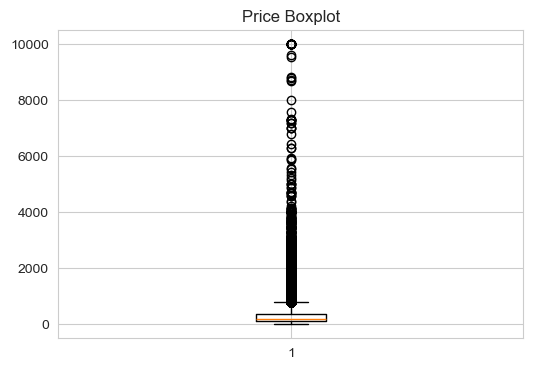

In [11]:

if 'price' in df.columns:
    plt.figure(figsize=(6,4))
    plt.boxplot(df['price'])
    plt.title('Price Boxplot')
    plt.show()

In [12]:
print("""
Analysis Insight:
The price distribution is highly skewed, with most projects having lower costs and a few very expensive ones. 
This is why a log scale is used to better visualize the distribution.
The boxplot shows the presence of outliers, indicating that some projects request significantly higher funding amounts.
These patterns suggest that price may influence project approval and should be considered during modeling.
""")


Analysis Insight:
The price distribution is highly skewed, with most projects having lower costs and a few very expensive ones. 
This is why a log scale is used to better visualize the distribution.
The boxplot shows the presence of outliers, indicating that some projects request significantly higher funding amounts.
These patterns suggest that price may influence project approval and should be considered during modeling.



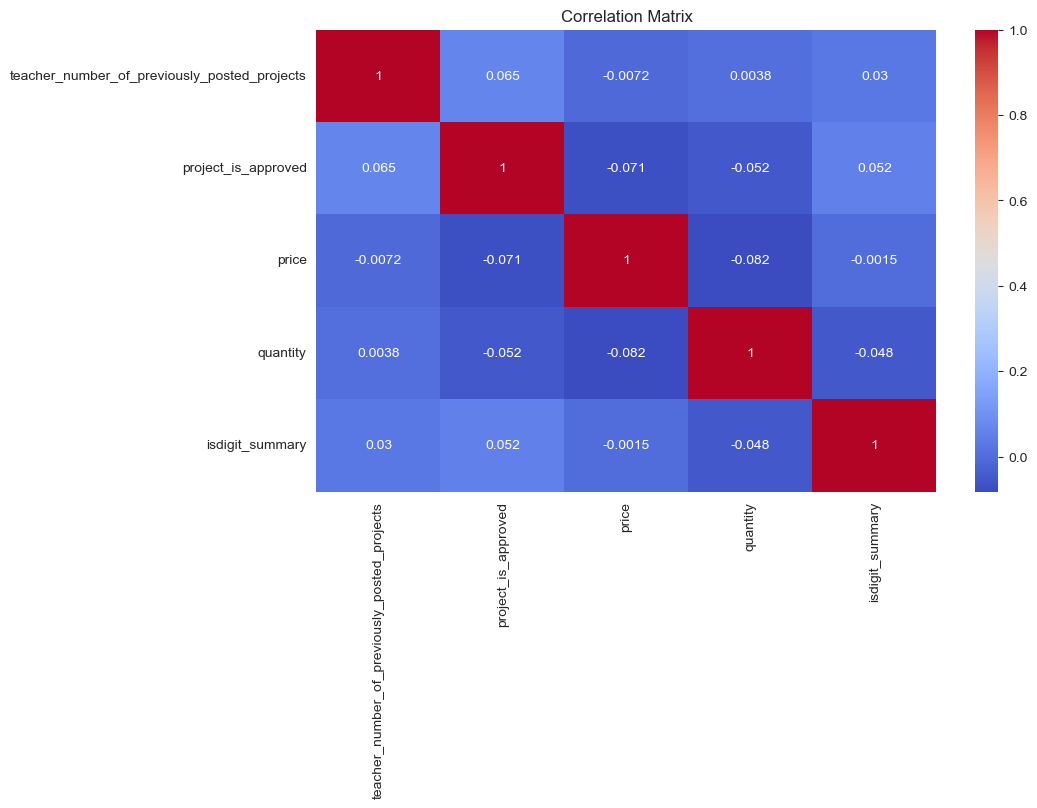

In [13]:
# TODO: Perform bivariate/multivariate analysis — explore relationships between features.
# Example: Correlation heatmap

import seaborn as sns

plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')  
plt.title('Correlation Matrix')
plt.show()

In [14]:
# TODO: Document any initial insights or hypotheses from your exploration.

initial_insights = [
    "Projects with lower prices appear more frequently and may have higher approval likelihood.",
    "There is a noticeable imbalance in project categories, with some subjects appearing more often than others.",
    "Teachers with more previously posted projects may have higher chances of approval.",
    "The dataset is highly skewed in terms of price, requiring transformations such as log scaling.",
    "Approval outcomes are likely influenced by a combination of features rather than a single dominant variable."
]
print(" INITIAL INSIGHTS ")
for i, insight in enumerate(initial_insights, 1):
    print(f"{i}. {insight}")

 INITIAL INSIGHTS 
1. Projects with lower prices appear more frequently and may have higher approval likelihood.
2. There is a noticeable imbalance in project categories, with some subjects appearing more often than others.
3. Teachers with more previously posted projects may have higher chances of approval.
4. The dataset is highly skewed in terms of price, requiring transformations such as log scaling.
5. Approval outcomes are likely influenced by a combination of features rather than a single dominant variable.


---
### Task 4: Verify Data Quality

Evaluate the completeness and correctness of the data. Check for problems that could affect the analysis:

- **Missing Values:** Identify columns with missing data, the volume, and patterns of missingness.
- **Duplicates:** Check for and report duplicate records.
- **Outliers:** Detect anomalous values using statistical methods or visualisations (box plots, z-scores).
- **Inconsistencies:** Look for data type mismatches, inconsistent formatting, or invalid entries.

**Instructions:** Systematically check for data quality issues and document your findings.

In [15]:
# TODO: Check for missing values.

# missing = df.isnull().sum()
# missing_pct = (df.isnull().sum() / len(df)) * 100
# missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
# missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
# print("=== Missing Values Report ===")
# print(missing_report)
# print(f"\nTotal columns with missing values: {len(missing_report)}")

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

missing_report = missing_report[missing_report['Missing Count'] > 0] \
                    .sort_values('Missing %', ascending=False)

print("=== MISSING VALUES REPORT ===")

if missing_report.empty:
    print("No missing values detected in the dataset.")
else:
    display(missing_report)

print(f"\nTotal columns with missing values: {len(missing_report)}")

=== MISSING VALUES REPORT ===


,Missing Count,Missing %
cleaned_titles,43,0.03936



Total columns with missing values: 1


In [16]:
# TODO: Check for duplicate records.

duplicates = df.duplicated().sum()

print("=== DUPLICATE RECORDS CHECK ===")
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    print("\nSample of duplicate rows:")
    display(df[df.duplicated(keep=False)].head(10))
else:
    print("No duplicate records found.")

=== DUPLICATE RECORDS CHECK ===
Number of duplicate rows: 0
No duplicate records found.


In [17]:
print("""
Data Quality Insight:

The dataset shows minimal or no missing values across most columns, indicating good data completeness.
Where missing values exist, they may need to be handled during the data preparation phase 
using techniques such as imputation or removal, depending on their impact.
Overall, the dataset appears reliable for further analysis and modeling.
""")


Data Quality Insight:

The dataset shows minimal or no missing values across most columns, indicating good data completeness.
Where missing values exist, they may need to be handled during the data preparation phase 
using techniques such as imputation or removal, depending on their impact.
Overall, the dataset appears reliable for further analysis and modeling.



=== OUTLIER CHECK USING BOX PLOTS ===
Numerical columns: ['teacher_number_of_previously_posted_projects', 'project_is_approved', 'price', 'quantity', 'isdigit_summary']


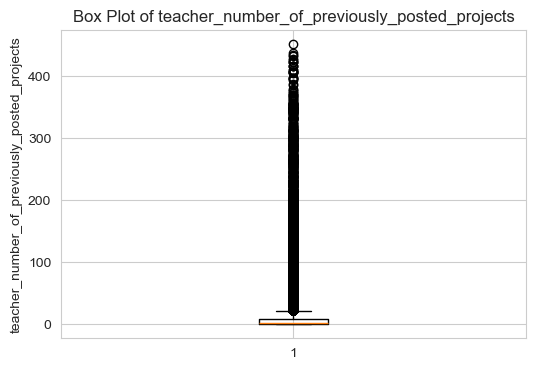

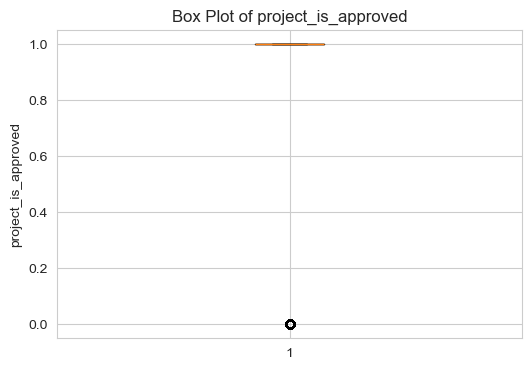

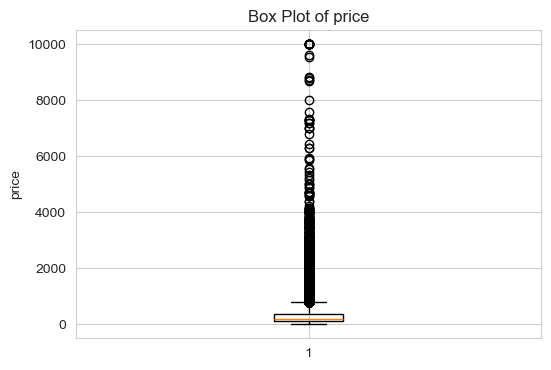

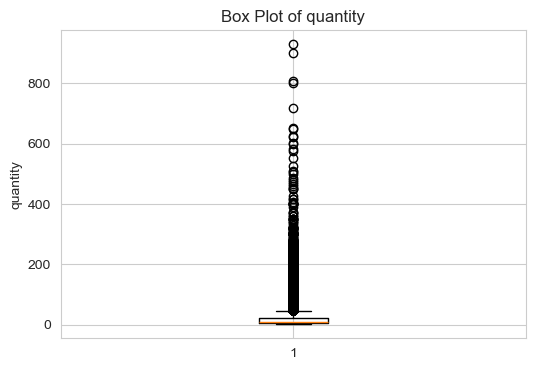

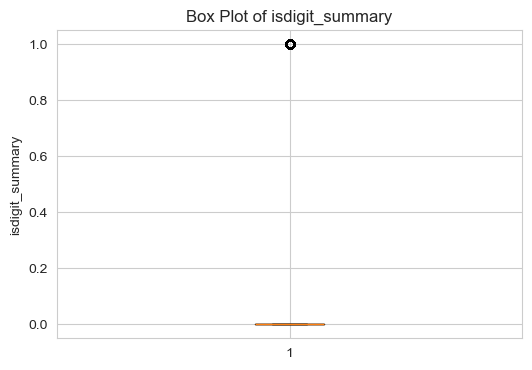

In [18]:
# TODO: Detect outliers using box plots or statistical methods.

# numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# if numerical_cols:
#     fig, axes = plt.subplots(nrows=1, ncols=len(numerical_cols), figsize=(4 * len(numerical_cols), 5))
#     if len(numerical_cols) == 1:
#         axes = [axes]
#     for ax, col in zip(axes, numerical_cols):
#         ax.boxplot(df[col].dropna())
#         ax.set_title(col)
#     plt.suptitle('Box Plots — Outlier Detection', fontsize=14, y=1.02)
#     plt.tight_layout()
#     plt.show()

import numpy as np
import matplotlib.pyplot as plt

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

print("=== OUTLIER CHECK USING BOX PLOTS ===")
print("Numerical columns:", numerical_cols)

for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()